# Global Cybersecurity Severity Prediction
This notebook is a **starting kit** to help you understand the dataset, train a simple baseline model, and generate **local submission files** compatible with the Codabench ingestion.


## Introduction

### Goal
Predict the **severity level of a cybersecurity incident** using the provided features.  
The objective is a **multi-class classification task** where each incident must be assigned to one of the following severity categories:

- `Low`
- `Medium`
- `High`
- `Critical`

### Severity Label Creation

The dataset contains several attributes describing cybersecurity incidents, including:

- `Number of Affected Users`
- `Incident Resolution Time (in Hours)`
- `Attack Type`
- `Security Vulnerability Type`
- `Target Industry`
- `Defense Mechanism Used`
- `Attack Source`
- `Country`
- `Year`

The original dataset did not include a ready-to-use severity label.  
Therefore, the **Severity Level was created during the data preparation step** in the script: tools/setup_data.py


The label was derived from indicators reflecting the **impact and seriousness of an incident**, mainly:

- the **number of affected users**
- the **incident resolution time**

These indicators were combined using predefined thresholds to categorize incidents into four levels:

| Severity | Description |
|--------|-------------|
| Low | Limited impact, few affected users, quick resolution |
| Medium | Moderate impact with manageable disruption |
| High | Significant impact affecting many users or requiring longer resolution |
| Critical | Severe incidents with large-scale impact or very long resolution time |

This transformation converts the problem into a **multi-class classification task**, where the model learns to predict the severity category from the incident features.

### Data Layout in this Repository

- **Training features**  
  `dev_phase/input_data/train/train_features.csv`

- **Training labels**  
  `dev_phase/input_data/train/train_labels.csv`  
  Column: `label`

- **Public test features**  
  `dev_phase/input_data/test/test_features.csv`

- **Private test features**  
  `dev_phase/input_data/private_test/private_test_features.csv`

The corresponding **ground truth labels used for evaluation** are stored in: dev_phase/reference_data/


- **Public labels**  
  `dev_phase/reference_data/test_labels.csv`

- **Private labels**  
  `dev_phase/reference_data/private_test_labels.csv`


# Exploratory data analysis

In this section we:
- Load the training data
- inspect the dataset dimensions
- check column types (categorical vs numerical)
- detect potential missing values
- analyze the distribution of the target variable (`label`)

This step helps verify the consistency of the data and understand the characteristics of the classification task.


X_df shape: (2386, 9)
y_df shape: (2386, 1)


,Country,Year,Attack Type,Target Industry,Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,605895,Hacker Group,Weak Passwords,VPN,20
3,Germany,2018,Man-in-the-Middle,IT,810682,Insider,Social Engineering,VPN,68
4,Germany,2017,Man-in-the-Middle,Retail,285201,Unknown,Social Engineering,Antivirus,25


,label
0,Critical
1,Critical
2,Medium
3,Critical
4,High



Column types:


Country                                object
Year                                    int64
Attack Type                            object
Target Industry                        object
Number of Affected Users                int64
Attack Source                          object
Security Vulnerability Type            object
Defense Mechanism Used                 object
Incident Resolution Time (in Hours)     int64
dtype: object


Missing values (top 20):


Country                                0.0
Year                                   0.0
Attack Type                            0.0
Target Industry                        0.0
Number of Affected Users               0.0
Attack Source                          0.0
Security Vulnerability Type            0.0
Defense Mechanism Used                 0.0
Incident Resolution Time (in Hours)    0.0
dtype: float64


Target distribution:


label
Medium      600
High        597
Low         595
Critical    594
Name: count, dtype: int64

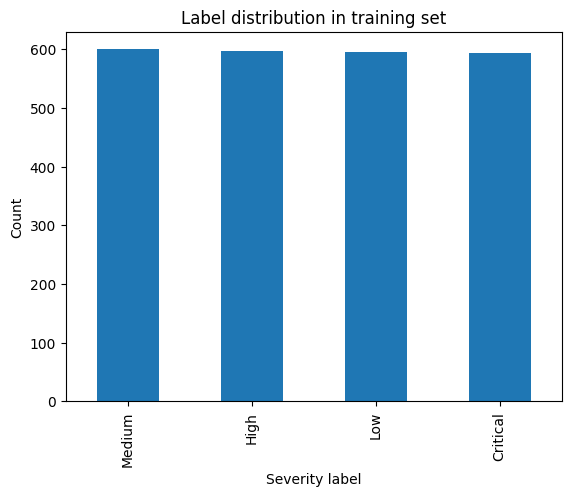

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# Paths
TRAIN_X_PATH = "dev_phase/input_data/train/train_features.csv"
TRAIN_Y_PATH = "dev_phase/input_data/train/train_labels.csv"

# Load training data
X_df = pd.read_csv(TRAIN_X_PATH)
y_df = pd.read_csv(TRAIN_Y_PATH)

print("X_df shape:", X_df.shape)
print("y_df shape:", y_df.shape)

display(X_df.head())
display(y_df.head())

# Inspect column types
print("\nColumn types:")
display(X_df.dtypes)

# Check missing values
print("\nMissing values (top 20):")
missing = X_df.isna().mean().sort_values(ascending=False)
display(missing.head(20))

# Target distribution
print("\nTarget distribution:")
label_counts = y_df["label"].value_counts()
display(label_counts)

# Plot target distribution
label_counts.plot(kind="bar")
plt.title("Label distribution in training set")
plt.xlabel("Severity label")
plt.ylabel("Count")
plt.show()



The exploratory analysis performed, provides several insights about the dataset.

### Dataset size

The training dataset contains:

- **2386 samples**
- **9 input features**
- **1 target variable (`label`)**

Each row represents a simulated cybersecurity incident.

### Feature types

The dataset contains both **categorical** and **numerical** variables.

Categorical variables include:

- `Country`
- `Attack Type`
- `Target Industry`
- `Attack Source`
- `Security Vulnerability Type`
- `Defense Mechanism Used`

Numerical variables include:

- `Year`
- `Number of Affected Users`
- `Incident Resolution Time (in Hours)`

This mixture of feature types requires preprocessing steps such as **one-hot encoding for categorical variables** before training a machine learning model.

### Missing values

The exploratory analysis shows that **no missing values are present in the dataset**.  
All columns contain complete data, which simplifies preprocessing.

### Target distribution

The severity label distribution in the training set is:

| Label | Count |
|------|------|
| Medium | 600 |
| High | 597 |
| Low | 595 |
| Critical | 594 |

The dataset is therefore **almost perfectly balanced across the four classes**.

This is beneficial for training a machine learning model, as it prevents bias toward a dominant class and makes the **Macro F1-score** an appropriate evaluation metric.

### Interpretation

From the exploratory analysis, we observe that:

- the dataset contains both categorical and numerical features describing cybersecurity incidents
- the classes are well balanced
- there are no missing values

These properties make the dataset well suited for a **multi-class classification problem** and allow participants to focus mainly on feature preprocessing and model design.

# Relationship between impact variables and severity level

Relationship between impact variables and severity level


<Figure size 640x480 with 0 Axes>

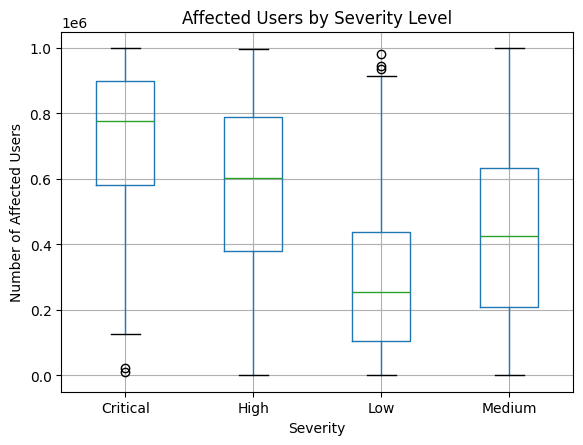

<Figure size 640x480 with 0 Axes>

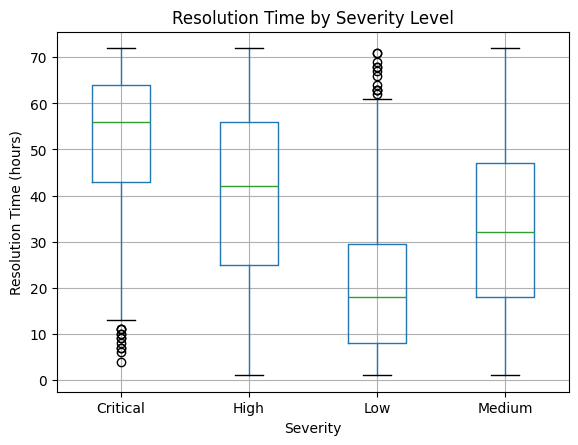

In [4]:
# Merge features and labels
df = X_df.copy()
df["label"] = y_df["label"]

print("Relationship between impact variables and severity level")

# Boxplot: affected users vs severity
plt.figure()
df.boxplot(column="Number of Affected Users", by="label")
plt.title("Affected Users by Severity Level")
plt.suptitle("")
plt.xlabel("Severity")
plt.ylabel("Number of Affected Users")
plt.show()

# Boxplot: resolution time vs severity
plt.figure()
df.boxplot(column="Incident Resolution Time (in Hours)", by="label")
plt.title("Resolution Time by Severity Level")
plt.suptitle("")
plt.xlabel("Severity")
plt.ylabel("Resolution Time (hours)")
plt.show()

### Relationship between features and severity level

To better understand whether the prediction task is meaningful, we analyze the relationship between key impact-related features and the severity label.

Two important variables are considered:

- **Number of Affected Users**
- **Incident Resolution Time (in Hours)**

The boxplots above show the distribution of these variables across the four severity levels.

#### Observations

From the plots, we observe that:

- incidents labeled **Critical** tend to affect a larger number of users
- incidents with **High** or **Critical** severity generally have longer resolution times
- **Low severity incidents** tend to affect fewer users and require less time to resolve

These patterns confirm that the severity label is consistent with the underlying incident characteristics.

#### Interpretation

The presence of clear differences between severity levels indicates that the dataset contains useful information for predicting the target variable.

This supports the idea that the task can be effectively modeled as a **multi-class classification problem**, where machine learning algorithms learn to map incident characteristics to a severity category.

# Challenge evaluation

### Metric: Macro F1 (multi class)
We evaluate predictions with **Macro F1**:
- Compute an F1 score for each class
- Take the unweighted average across classes

Macro F1 is a good choice when classes are imbalanced because it treats all classes equally.

### Public vs Private
The public leaderboard uses the **public test** set. The private test set is used for the **final** score.

### Temporal split for local validation
When possible, we recommend a **temporal split** on the training data:
- Train on earlier samples
- Validate on later samples

This reduces leakage and better matches a real use case where you predict on future events.


# Submission format

Your submission must produce **two CSV files**:

- `test_predictions.csv` for the public test set
- `private_test_predictions.csv` for the private test set

Each file must contain a single column named `label` with one prediction per row, using the exact label names:
`Low`, `Medium`, `High`, `Critical`.


## The prediction files

Example content of `test_predictions.csv`:

```
label
Low
High
Medium
...
```

Important:
- No extra columns
- Same number of rows as the corresponding `*_features.csv`
- Order must match the order of the feature file rows


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def find_time_column(df: pd.DataFrame):
    '''
    Try to find a column that looks like time. If found, it is used for a temporal split.
    Returns the column name or None.
    '''
    keywords = ["date", "time", "timestamp", "created", "updated", "published", "day", "month", "year"]
    candidates = [c for c in df.columns if any(k in c.lower() for k in keywords)]

    for c in candidates:
        s = pd.to_datetime(df[c], errors="coerce", utc=False)
        # keep if most values parse to datetime
        if s.notna().mean() >= 0.8:
            return c
    return None


def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = list(X.select_dtypes(include=["number", "bool"]).columns)
    cat_cols = [c for c in X.columns if c not in num_cols]

    numeric_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols),
        ]
    )


def get_baseline_model(X: pd.DataFrame) -> Pipeline:
    preprocessor = make_preprocessor(X)
    clf = LogisticRegression(max_iter=2000, class_weight="balanced")
    return Pipeline(steps=[("preprocess", preprocessor), ("model", clf)])


## Local testing pipeline

Below we:
1) Build a temporal validation split when possible
2) Train the baseline model
3) Evaluate it with **Macro F1**
4) Retrain on all training data
5) Generate `test_predictions.csv` and `private_test_predictions.csv`


In [7]:
from pathlib import Path

# Load full training data
X = pd.read_csv(TRAIN_X_PATH)
y = pd.read_csv(TRAIN_Y_PATH)["label"].astype(str)

# 1) Temporal split if possible
time_col = find_time_column(X)
if time_col is not None:
    X_sorted = X.copy()
    X_sorted[time_col] = pd.to_datetime(X_sorted[time_col], errors="coerce")
    X_sorted = X_sorted.sort_values(time_col)

    y_sorted = y.loc[X_sorted.index]

    split_idx = int(0.8 * len(X_sorted))
    X_train, X_val = X_sorted.iloc[:split_idx], X_sorted.iloc[split_idx:]
    y_train, y_val = y_sorted.iloc[:split_idx], y_sorted.iloc[split_idx:]

    print(f"Using temporal split on column: {time_col}")
else:
    # Fallback: random split (stratified)
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print("No time-like column found. Using stratified random split.")

# 2) Train baseline
model = get_baseline_model(X_train)
model.fit(X_train, y_train)

# 3) Evaluate with Macro F1
val_pred = model.predict(X_val)
val_f1 = f1_score(y_val, val_pred, average="macro")
print("Validation Macro F1:", val_f1)

# 4) Retrain on full training set
model = get_baseline_model(X)
model.fit(X, y)

# 5) Predict on public and private test, and write local submission files
TEST_X_PATH = "dev_phase/input_data/test/test_features.csv"
PRIVATE_TEST_X_PATH = "dev_phase/input_data/private_test/private_test_features.csv"

X_test = pd.read_csv(TEST_X_PATH)
X_private = pd.read_csv(PRIVATE_TEST_X_PATH)

pred_test = model.predict(X_test)
pred_private = model.predict(X_private)

submission_dir = Path("local_submission")
submission_dir.mkdir(exist_ok=True)

pd.DataFrame({"label": pred_test}).to_csv(submission_dir / "test_predictions.csv", index=False)
pd.DataFrame({"label": pred_private}).to_csv(submission_dir / "private_test_predictions.csv", index=False)

print("Wrote submission files to:", submission_dir.resolve())
print(" -", (submission_dir / "test_predictions.csv").name)
print(" -", (submission_dir / "private_test_predictions.csv").name)


Using temporal split on column: Year
Validation Macro F1: 0.5619279041853669
Wrote submission files to: C:\Users\yasmi\Bureau\DataCamp\Group Project\cybersecurity-codabench-main\local_submission
 - test_predictions.csv
 - private_test_predictions.csv


# Submission

For local scoring, you can run the scoring program on the generated files:

```
python scoring_program/scoring.py --reference-dir dev_phase/reference_data --prediction-dir local_submission --output-dir scoring_res
```

On Codabench, your submission is typically a zip that contains your code (for example a `submission.py`) so that the ingestion program can:
- train your model using the training set
- generate predictions on `test_features.csv` and `private_test_features.csv`

Use the `Seed` page of the competition as a starting point and keep the output file format exactly as described above.


---

If you have questions about the expected file format or about the evaluation metric, check the competition pages or open an issue with the organizers.
